<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/10_computer_vision/fruit_recognition_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fruit Recognition System using CNN

In this project, we will build a Convolutional Neural Network (CNN) to classify fruit images.

The dataset contains three fruit classes:

- Apple
- Banana
- Orange

This is a multi-class image classification problem because the model must choose one class from more than two categories.

## Learning Objectives

- Load a custom image dataset
- Understand train and test folders
- Visualize fruit images
- Normalize image data
- Build a CNN model
- Train and evaluate the model
- Make predictions on fruit images

In [1]:
import zipfile
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 1: Extract the Dataset

The dataset is stored as a ZIP file.

First, upload `simple_fruit_dataset.zip` to Google Colab.

Then we extract the ZIP file so that Python can access the image folders.

In [2]:
with zipfile.ZipFile("simple_fruit_dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")

Dataset extracted successfully!


## Step 2: Define Dataset Paths

The dataset is organized into training and testing folders.

The training folder is used to teach the model.

The testing folder is used to evaluate the model on unseen images.

In [3]:
train_dir = "fruit_dataset/train"
test_dir = "fruit_dataset/test"

print("Training Path:", train_dir)
print("Testing Path:", test_dir)

Training Path: fruit_dataset/train
Testing Path: fruit_dataset/test


## Step 3: Check Dataset Classes

Each folder name represents one fruit class.

For this dataset, the classes are:

- Apple
- Banana
- Orange

In [4]:
print("Training Classes:", os.listdir(train_dir))
print("Testing Classes:", os.listdir(test_dir))

Training Classes: ['banana', 'orange', 'apple']
Testing Classes: ['banana', 'orange', 'apple']


## Step 4: Count Images in Each Class

Before training, it is useful to check how many images are available for each class.

A balanced dataset helps the model learn each class fairly.

In [5]:
for fruit in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, fruit)
    image_count = len(os.listdir(folder_path))
    print(fruit, ":", image_count, "training images")

banana : 80 training images
orange : 80 training images
apple : 80 training images


## Step 5: Load Dataset with TensorFlow

TensorFlow provides a simple function called `image_dataset_from_directory`.

It automatically:

- Reads images from folders
- Assigns labels based on folder names
- Resizes images
- Creates batches for training

In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 240 files belonging to 3 classes.
Found 60 files belonging to 3 classes.


## Step 6: View Class Names

TensorFlow automatically detects class names from folder names.

In [7]:
class_names = train_dataset.class_names

print("Class Names:", class_names)

Class Names: ['apple', 'banana', 'orange']


## Step 7: Visualize Sample Fruit Images

Before training, we should inspect the images.

This helps us confirm that the dataset loaded correctly.

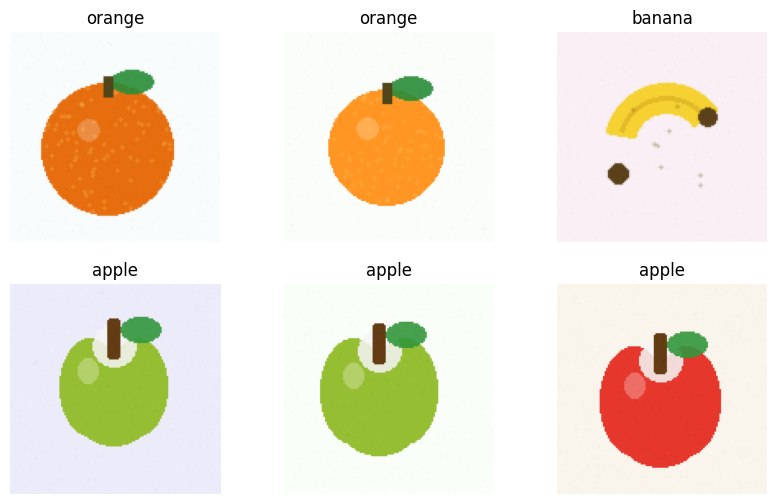

In [8]:
plt.figure(figsize=(10, 6))

for images, labels in train_dataset.take(1):
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Step 8: Normalize Pixel Values

Image pixel values normally range from 0 to 255.

Neural networks train better when input values are between 0 and 1.

We normalize images by dividing pixel values by 255.

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

## Step 9: Improve Dataset Performance

Prefetching helps load data faster while the model is training.

This makes training more efficient.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## Step 10: Build the CNN Model

A Convolutional Neural Network learns image patterns automatically.

The model contains:

- Convolution layers for feature extraction
- Pooling layers for reducing image size
- Flatten layer to convert features into a vector
- Dense layers for classification
- Softmax output for multi-class prediction

Since we have 3 fruit classes, the final layer has 3 neurons.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(3, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 11: Compile the Model

Before training, we configure the model.

For multi-class classification, we use:

- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Metric: Accuracy

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 12: Train the Model

The model learns from the training images.

Validation performance is measured using the test dataset.

In [13]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 597ms/step - accuracy: 0.5167 - loss: 0.9211 - val_accuracy: 0.8500 - val_loss: 0.3892
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 503ms/step - accuracy: 0.9250 - loss: 0.2242 - val_accuracy: 1.0000 - val_loss: 0.0246
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 593ms/step - accuracy: 0.9958 - loss: 0.0223 - val_accuracy: 1.0000 - val_loss: 2.0189e-04
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 606ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 5.3280e-04
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 503ms/step - accuracy: 0.9958 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 6.6116e-04


## Step 13: Evaluate the Model

Evaluation tells us how well the model performs on unseen test images.

In [14]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 6.6116e-04
Test Accuracy: 1.0
Test Loss: 0.0006611647550016642


## Step 14: Visualize Training Performance

Training and validation accuracy help us understand whether the model is learning properly.

If training accuracy is high but validation accuracy is low, the model may be overfitting.

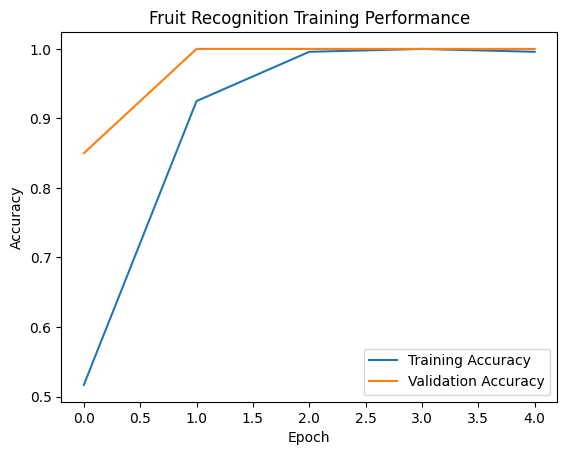

In [15]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Fruit Recognition Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Step 15: Make Predictions

Now we test the trained model on fruit images.

The model outputs probabilities for each class.

The class with the highest probability becomes the final prediction.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


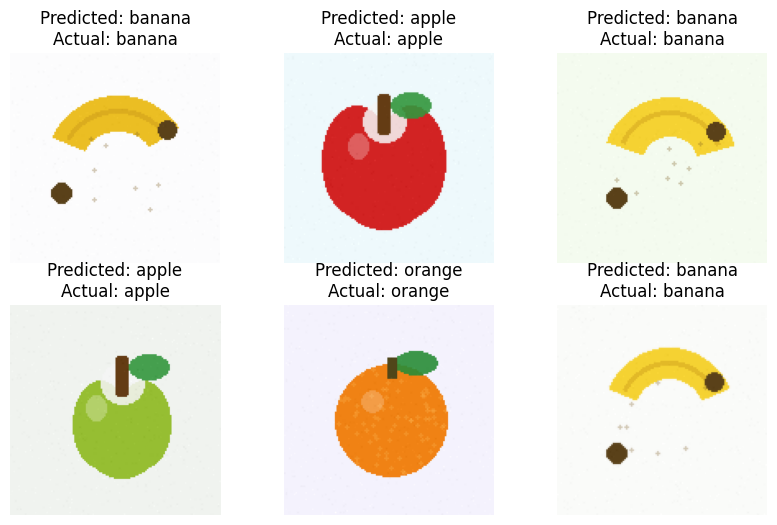

In [16]:
plt.figure(figsize=(10, 6))

for images, labels in test_dataset.take(1):
    predictions = model.predict(images)

    for i in range(6):
        plt.subplot(2, 3, i + 1)

        plt.imshow(images[i].numpy())

        predicted_class = class_names[np.argmax(predictions[i])]
        actual_class = class_names[labels[i]]

        plt.title(
            f"Predicted: {predicted_class}\nActual: {actual_class}"
        )

        plt.axis("off")

plt.show()

# Conclusion

In this project, we built a Fruit Recognition System using CNN.

## What I Learned

- How to load a custom image dataset
- How folder names become class labels
- How to visualize image samples
- How to normalize image data
- How to build a CNN model
- How to train and evaluate a multi-class classifier
- How to make predictions on fruit images

This project is a beginner-friendly step toward more advanced image classification systems such as skin lesion classification and MobileSkinXAI.